In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [22]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [23]:
df1 = df.copy()

In [24]:
df1

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [25]:
df1.head()
df1.shape
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [26]:
df1["Attrition"].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [27]:
#Checking for null values and duplicate row
df1.isnull().sum()   #no any null values here
df1.duplicated().sum()

np.int64(0)

In [28]:
#Numerical vs categorigal values 
num_cols = df1.select_dtypes(include=['int64','float64'])
cat_cols = df1.select_dtypes(include=['object'])

In [29]:
num_cols  #1470 * 26
cat_cols  #1470 * 9


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [86]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [31]:
# Numerical Features Analysis
# Key Observations
# EmployeeCount has a constant value of 1 for all employees and does not provide any useful information for prediction.
# StandardHours is constant (80 hours) across all records and can be considered a non-informative feature.
# EmployeeNumber appears to be a unique identifier rather than a business-related feature and is unlikely to contribute to attrition prediction.
# The employee age ranges from 18 to 60 years, with a median age of 36 years, indicating a workforce primarily composed of mid-career professionals.
# MonthlyIncome shows a large spread, ranging from 1009 to 19999. The mean income is higher than the median income, suggesting a potentially right-skewed distribution with some high-income employees.
# Employees have a median of 10 total working years and 5 years at the current company, indicating a mix of relatively new and experienced employees.
# The variable YearsSinceLastPromotion ranges from 0 to 15 years, suggesting that some employees have not received a promotion for a long period of time.
# Satisfaction-related variables such as JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, and WorkLifeBalance have median values around 3 on a 1–4 scale, indicating generally moderate to positive employee sentiment.
# Features Requiring Further Investigation

# The following numerical features may have a strong relationship with employee attrition and will be explored in the next stage of EDA:

# Age
# MonthlyIncome
# DistanceFromHome
# TotalWorkingYears
# YearsAtCompany
# YearsSinceLastPromotion
# WorkLifeBalance
# Next Steps
# Analyze the distribution of important numerical features using histograms.
# Identify potential outliers using boxplots.
# Examine the relationship between numerical features and the target variable (Attrition).
# Determine whether any numerical variables require transformation or scaling before model training.

In [32]:
df1 = df1.drop(
    columns=[
        'EmployeeCount',
        'StandardHours',
        'EmployeeNumber'
    ]
)
### Feature Removal

# The following features were removed from the dataset:

# - EmployeeCount: Constant value across all records.
# - StandardHours: Constant value across all records.
# - EmployeeNumber: Unique employee identifier with no predictive value.

# These features do not contribute meaningful information for attrition prediction and were removed before further analysis.

In [33]:
### Numerical Feature Categorization

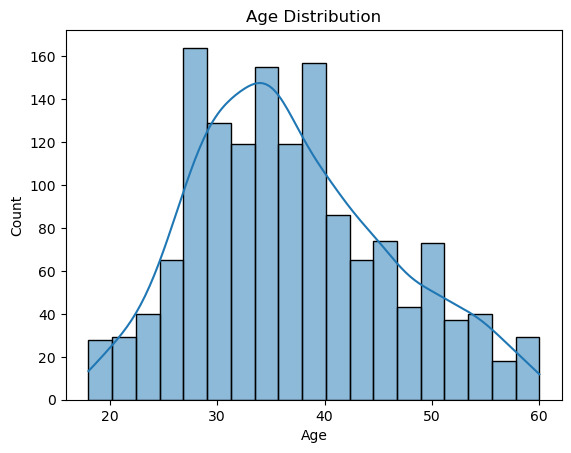

In [34]:
#AGE 
sns.histplot(df1["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

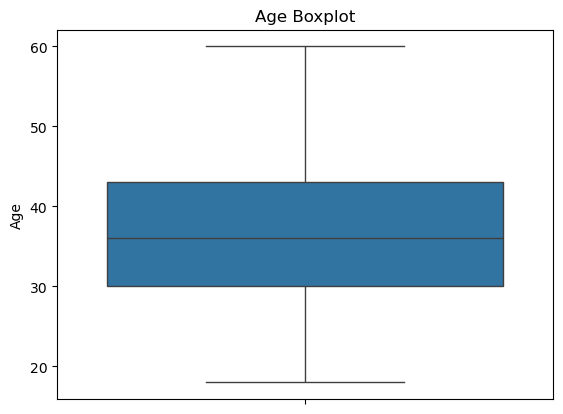

In [35]:
sns.boxplot(y=df1["Age"])
plt.title("Age Boxplot")
plt.show()

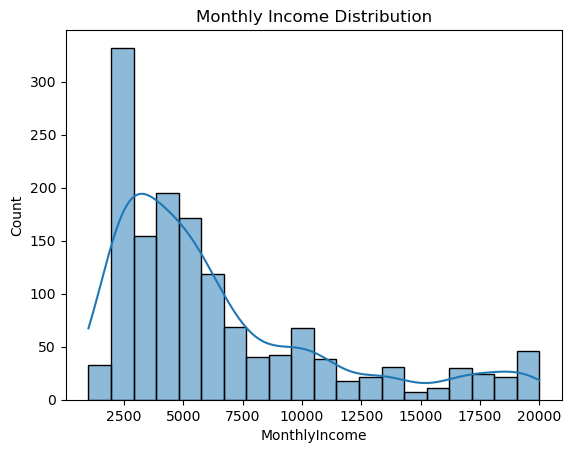

In [36]:
#MONTHLY INCOME 
sns.histplot(df1["MonthlyIncome"], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

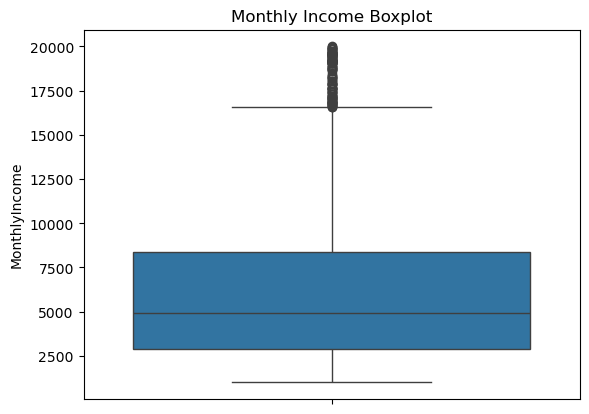

In [37]:
sns.boxplot(y=df1["MonthlyIncome"])
plt.title("Monthly Income Boxplot")
plt.show()

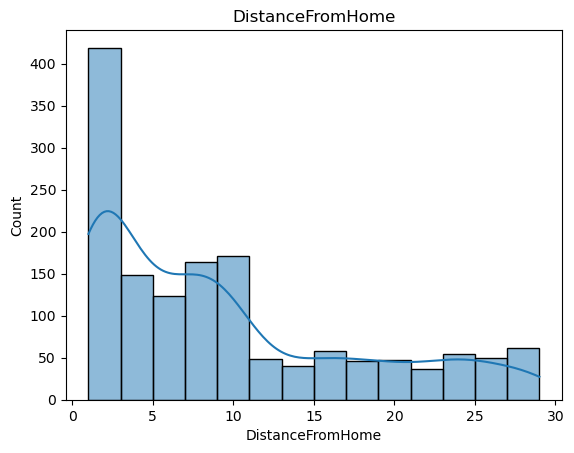

In [38]:
#DistanceFromHome
sns.histplot(df1["DistanceFromHome"], kde=True)
plt.title("DistanceFromHome")
plt.show()

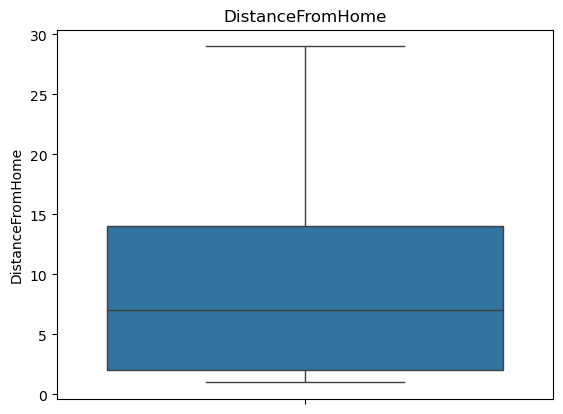

In [39]:
sns.boxplot(y=df1["DistanceFromHome"])
plt.title("DistanceFromHome")
plt.show()

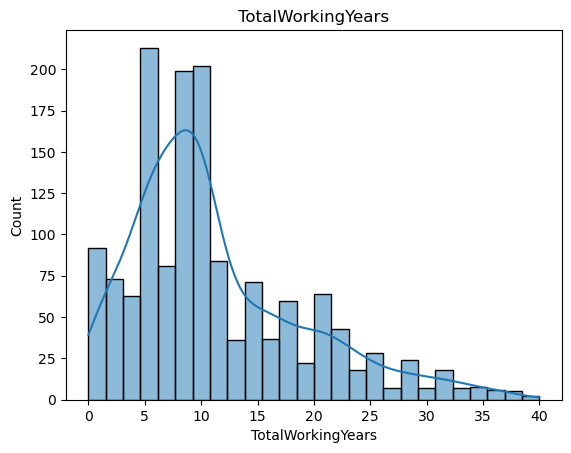

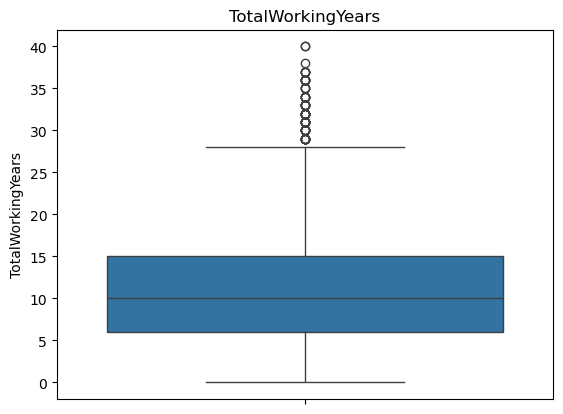

In [40]:
#Total Working Year 
sns.histplot(df1["TotalWorkingYears"], kde=True)
plt.title("TotalWorkingYears")
plt.show()
sns.boxplot(y=df1["TotalWorkingYears"])
plt.title("TotalWorkingYears")
plt.show()

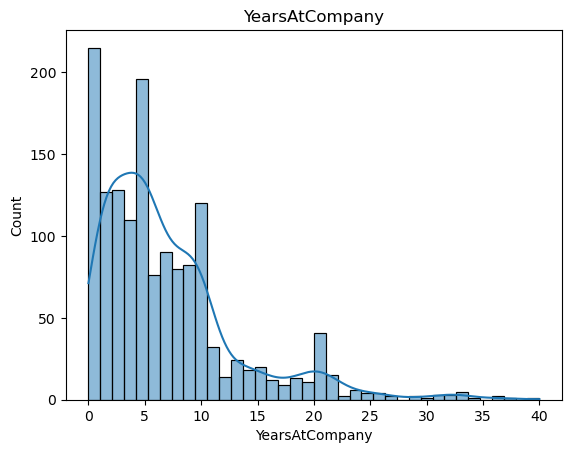

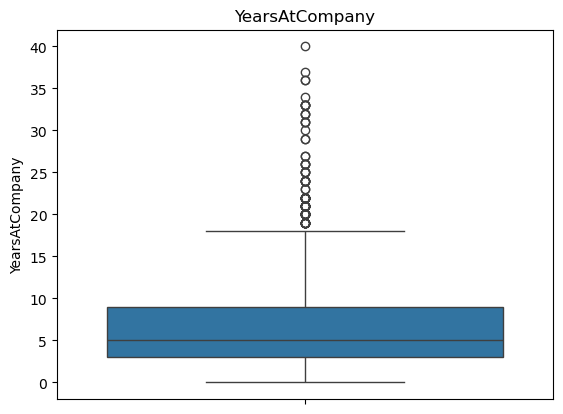

In [41]:
#Total Working Year 
sns.histplot(df1["YearsAtCompany"], kde=True)
plt.title("YearsAtCompany")
plt.show()
sns.boxplot(y=df1["YearsAtCompany"])
plt.title("YearsAtCompany")
plt.show()

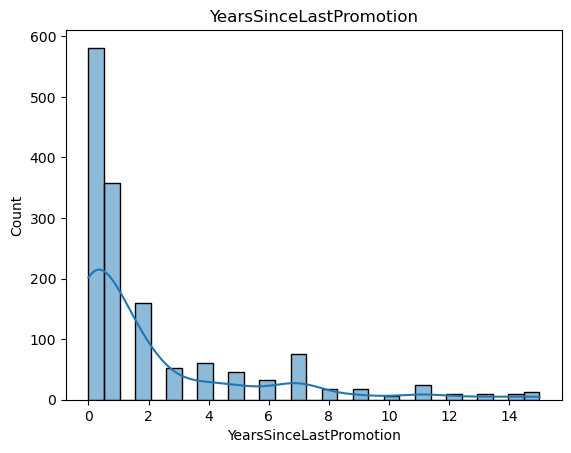

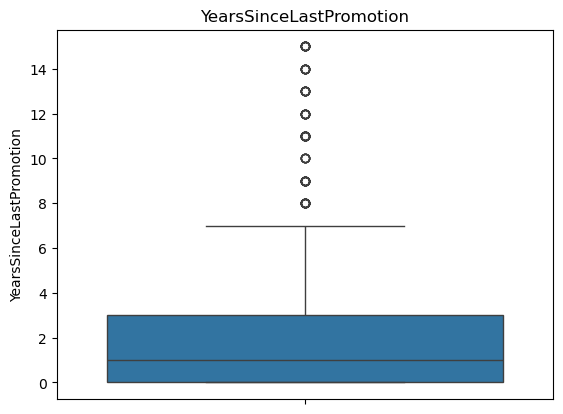

In [42]:
#YearsSinceLastPromotion
sns.histplot(df1["YearsSinceLastPromotion"], kde=True)
plt.title("YearsSinceLastPromotion")
plt.show()
sns.boxplot(y=df1["YearsSinceLastPromotion"])
plt.title("YearsSinceLastPromotion")
plt.show()

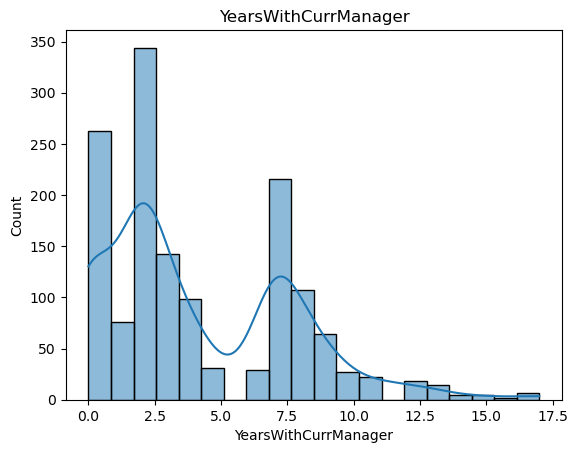

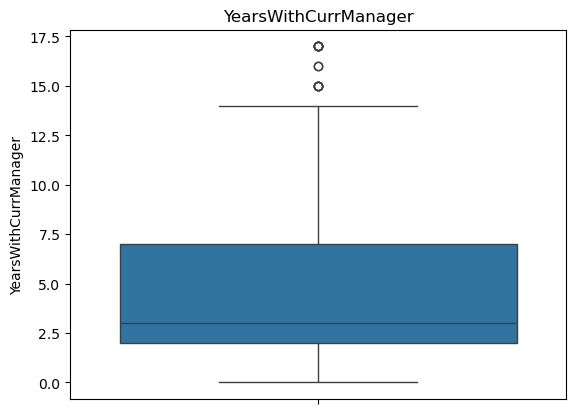

In [43]:
#Years with current manager 
sns.histplot(df1["YearsWithCurrManager"], kde=True)
plt.title("YearsWithCurrManager")
plt.show()
sns.boxplot(y=df1["YearsWithCurrManager"])
plt.title("YearsWithCurrManager")
plt.show()

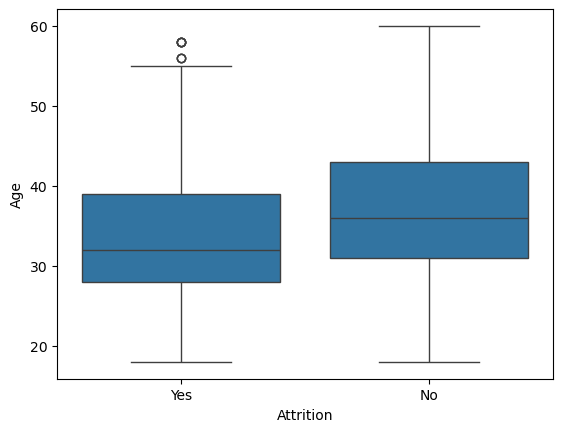

In [44]:
sns.boxplot(x="Attrition", y="Age", data=df1)
plt.show()

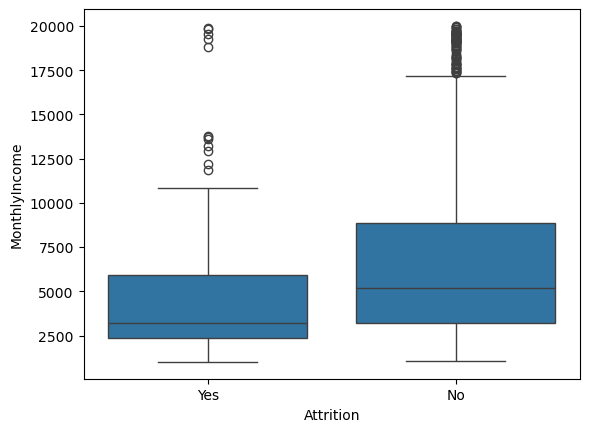

In [45]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df1)
plt.show()

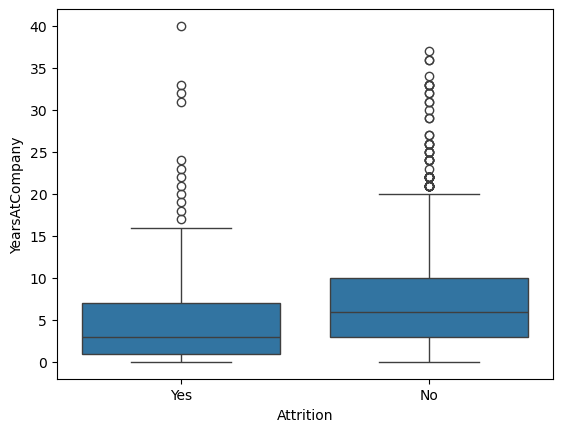

In [46]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df1)
plt.show()

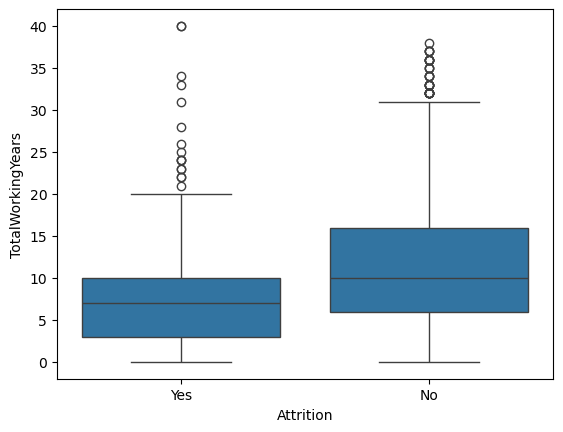

In [47]:
sns.boxplot(x="Attrition", y="TotalWorkingYears", data=df1)
plt.show()

In [48]:
## Key Numerical Insights

# 1. Younger employees show a higher tendency to leave the company.

# 2. Employees with lower monthly income are more likely to experience attrition.

# 3. Attrition is more common among employees with fewer years at the company.

# 4. Employees with lower overall work experience tend to leave more frequently.

# These findings suggest that age, compensation, tenure, and work experience may be important predictors of employee attrition.

In [49]:
## Categorical Feature Analysis

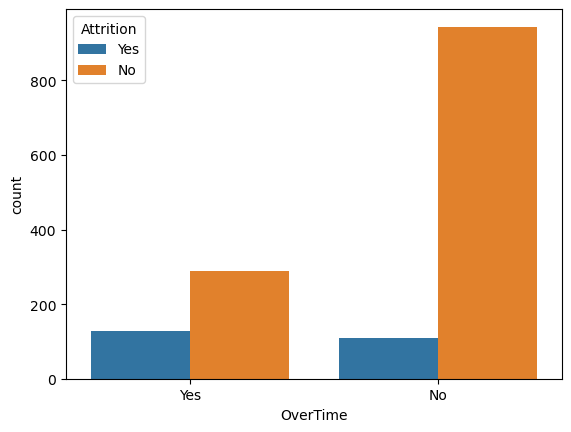

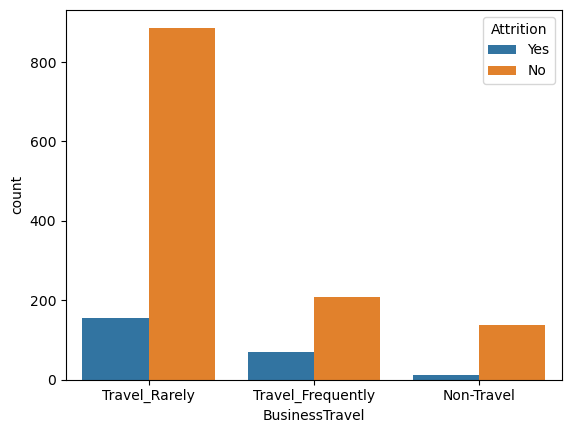

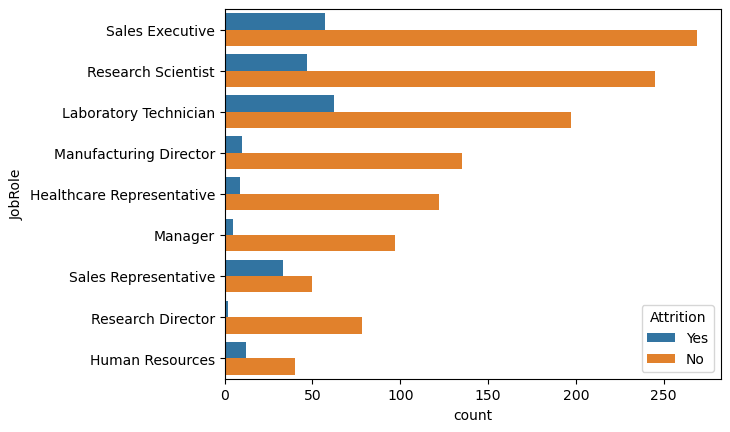

In [50]:
sns.countplot(x="OverTime", hue="Attrition", data=df1)
plt.show()
sns.countplot(x="BusinessTravel", hue="Attrition", data=df1)
plt.show()
sns.countplot(y="JobRole", hue="Attrition", data=df1)
plt.show()

In [51]:
## Key Categorical Insights

# 1. Employees working overtime show higher attrition compared to employees who do not work overtime.

# 2. Frequent business travel appears to be associated with increased employee turnover.

# 3. Attrition varies across job roles, indicating that certain roles may experience higher employee turnover than others.

# These findings suggest that work-related factors such as overtime, travel requirements, and job role may play an important role in employee attrition.

In [52]:
## Outlier Analysis

# Boxplots revealed the presence of outliers in several numerical features, including MonthlyIncome, YearsAtCompany, and TotalWorkingYears.

# After examining these values, they appear to represent legitimate employee records (e.g., senior employees with higher salaries and longer work experience) rather than data entry errors or invalid observations.

# Therefore, no outlier treatment was applied, and all observations were retained for further analysis and model development.

In [53]:
corr_matrix = df1.corr(numeric_only=True)
corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


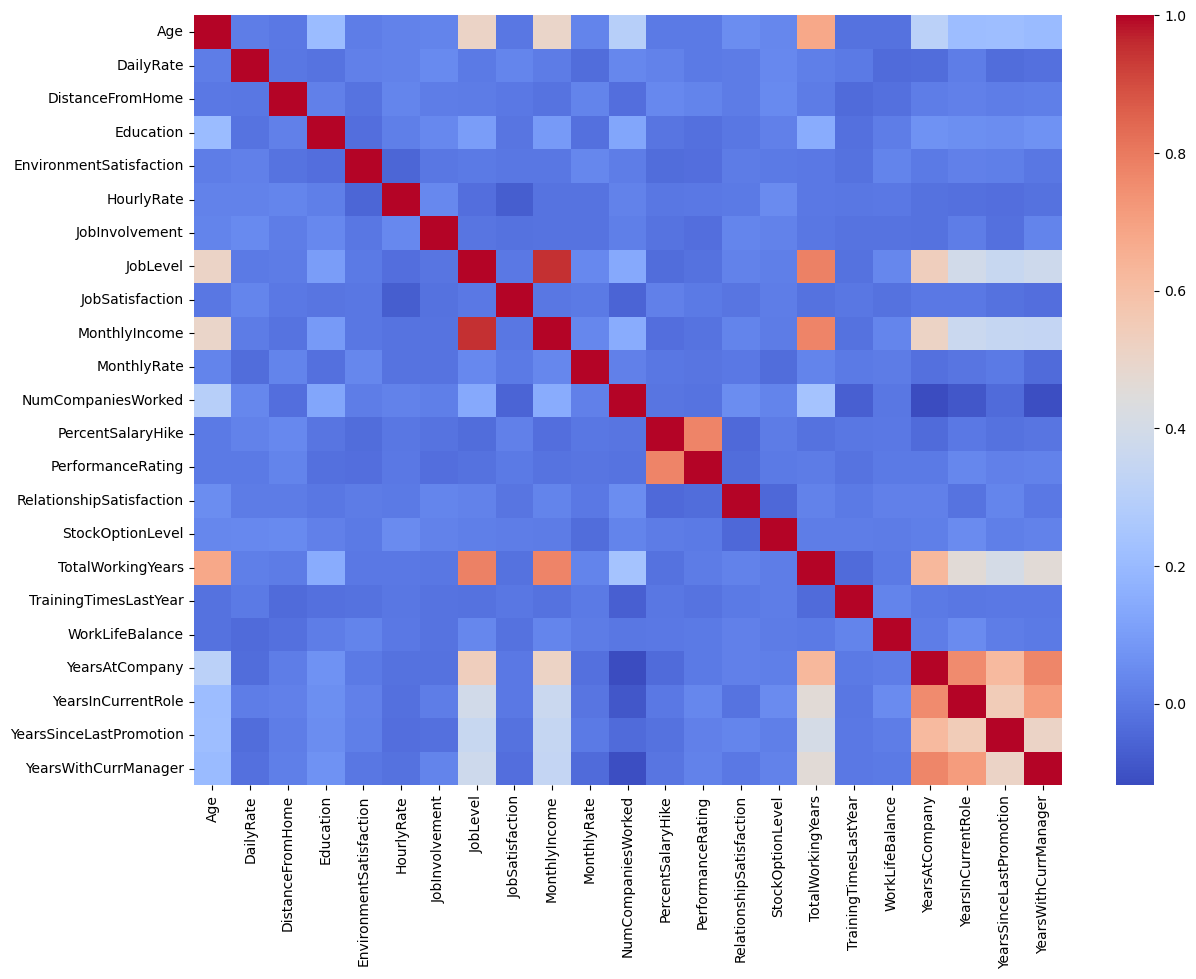

In [54]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df1.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [55]:
#Encoding
df1["Attrition"] = df1["Attrition"].map({
    "Yes":1,
    "No":0
})

In [56]:
corr = df1.corr(numeric_only=True)

corr["Attrition"].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition, dtype: float64

In [57]:
# ## Correlation with Attrition

# The correlation analysis indicates that no numerical feature has a strong linear relationship with Attrition.

# The strongest negative correlations were observed for:

# - TotalWorkingYears (-0.17)
# - JobLevel (-0.17)
# - YearsInCurrentRole (-0.16)
# - MonthlyIncome (-0.16)
# - Age (-0.16)

# These results suggest that employees with greater experience, higher job levels, longer tenure, and higher income tend to have lower attrition rates.

# However, the correlations are relatively weak, indicating that employee attrition is likely influenced by a combination of multiple factors rather than a single variable.

In [58]:

df1["Gender"] = df1["Gender"].map({
    "Male": 1,
    "Female": 0
})
df1["OverTime"] = df1["OverTime"].map({
    "Yes": 1,
    "No": 0
})

In [59]:
#one hot encoding 
df_encoded = pd.get_dummies(
    df1,
    columns=[
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus"
    ],
    drop_first=True
)

In [60]:
df_encoded

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,False,True,False,True,False


In [61]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                1470 non-null   int64 
 1   Attrition                          1470 non-null   int64 
 2   DailyRate                          1470 non-null   int64 
 3   DistanceFromHome                   1470 non-null   int64 
 4   Education                          1470 non-null   int64 
 5   EnvironmentSatisfaction            1470 non-null   int64 
 6   Gender                             1470 non-null   int64 
 7   HourlyRate                         1470 non-null   int64 
 8   JobInvolvement                     1470 non-null   int64 
 9   JobLevel                           1470 non-null   int64 
 10  JobSatisfaction                    1470 non-null   int64 
 11  MonthlyIncome                      1470 non-null   int64 
 12  Monthl

In [62]:
df_encoded.drop("Over18", axis=1, inplace=True)  #over 18 hi hoga banda

In [63]:
bool_cols = df_encoded.select_dtypes(include="bool").columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [64]:
corr_target = (
    df_encoded.corr()["Attrition"]
    .sort_values(ascending=False)
)

corr_target

Attrition                            1.000000
OverTime                             0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender                               0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences      

In [65]:
## Correlation Analysis with Attrition

# The strongest positive correlation with Attrition was observed for OverTime (0.246), indicating that employees who work overtime are more likely to leave the company.

# Other factors positively associated with attrition include:
# - Being single
# - Frequent business travel
# - Sales Representative role
# - Laboratory Technician role

# The strongest negative correlations were observed for:
# - TotalWorkingYears
# - JobLevel
# - YearsInCurrentRole
# - MonthlyIncome
# - Age

# These findings suggest that experienced, higher-paid, and more senior employees tend to remain with the organization, while workload and certain job roles may be associated with higher employee turnover.

# Overall, no feature shows a very strong linear relationship with attrition, indicating that employee turnover is influenced by a combination of multiple factors.

In [66]:
############ ------------------EDA-----------------################

In [67]:
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

In [68]:
from sklearn.model_selection import train_test_split
X1_train , X1_test , Y1_train, Y1_test = train_test_split(X,y,test_size = 0.2 , random_state=42,
    stratify=y)

In [69]:
#SMOTE ALGORITHM 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42,sampling_strategy=0.6)

X1_train_res, Y1_train_res = smote.fit_resample(X1_train, Y1_train)

In [70]:
print(Y1_train.value_counts())
print(Y1_train_res.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    986
1    591
Name: count, dtype: int64


In [109]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 7000, C= 0.5, random_state = 42, solver='liblinear')
model.fit(X1_train_res, Y1_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,7000
,multi_class,'deprecated'


In [110]:
from sklearn.metrics import classification_report

y1_pred = model.predict(X1_test)

print(classification_report(Y1_test, y1_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       247
           1       0.53      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.71      0.67      0.68       294
weighted avg       0.83      0.85      0.84       294



In [73]:
from sklearn.metrics import accuracy_score, precision_score



# accuracy
acc = accuracy_score(Y1_test, y1_pred)
print("Accuracy:", acc)

# precision (class 1 ke liye default)
prec = precision_score(Y1_test, y1_pred)
print("Precision:", prec)

Accuracy: 0.8469387755102041
Precision: 0.5263157894736842


In [74]:
#######Second Model###########

In [75]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. pipeline (NO threshold here)
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.6, random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000, C=0.5))
])

# 3. train
pipeline.fit(X_train, y_train)

# 4. probabilities 
y_prob = pipeline.predict_proba(X_test)[:, 1]

# 5. threshold = 0.6
y_pred = (y_prob > 0.6).astype(int)

# 6. evaluation
from sklearn.metrics import accuracy_score, precision_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8775510204081632
Precision: 0.72
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.72      0.38      0.50        47

    accuracy                           0.88       294
   macro avg       0.81      0.68      0.72       294
weighted avg       0.86      0.88      0.86       294



In [76]:
y_prob = model.predict_proba(X_test)[:, 1]

In [92]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

In [93]:
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])

Best Threshold: 0.4279232078771072
Best F1 Score: 0.505263152895291


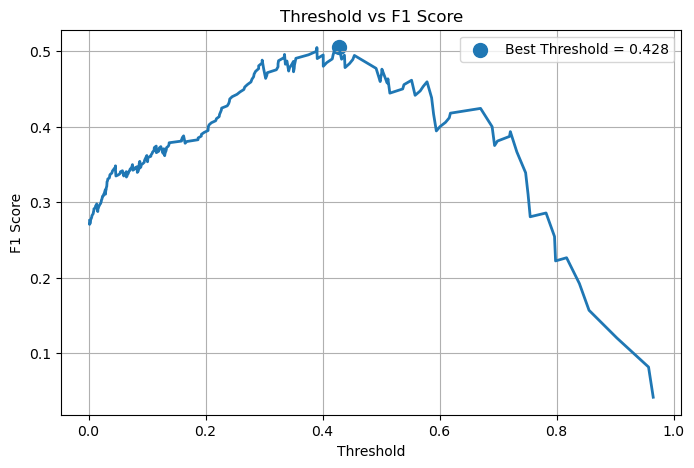

In [94]:

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores[:-1], linewidth=2)

plt.scatter(
    best_threshold,
    f1_scores[:-1][best_idx],
    s=100,
    label=f'Best Threshold = {best_threshold:.3f}'
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.legend()
plt.grid(True)

plt.show()

In [79]:
y_pred_best = (y_prob >= best_threshold).astype(int)

In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       247
           1       0.50      0.51      0.51        47

    accuracy                           0.84       294
   macro avg       0.70      0.71      0.70       294
weighted avg       0.84      0.84      0.84       294



AUC Score: 0.755


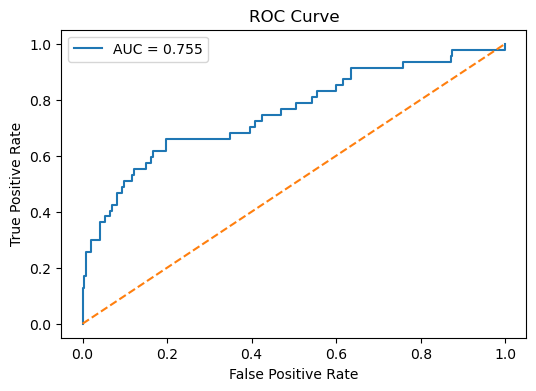

In [98]:
#ROC CURVE 
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", round(auc,3))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

                             Feature  Coefficient
15                 PerformanceRating     1.673375
13                          OverTime     1.261108
35     JobRole_Laboratory Technician     0.481024
12                NumCompaniesWorked     0.166105
23           YearsSinceLastPromotion     0.138149
25  BusinessTravel_Travel_Frequently     0.125073
41      JobRole_Sales Representative     0.112611
2                   DistanceFromHome     0.044348
21                    YearsAtCompany     0.037962
6                         HourlyRate     0.009777
0                                Age     0.005550
5                             Gender     0.004096
10                     MonthlyIncome     0.000062
11                       MonthlyRate     0.000025
1                          DailyRate    -0.000129


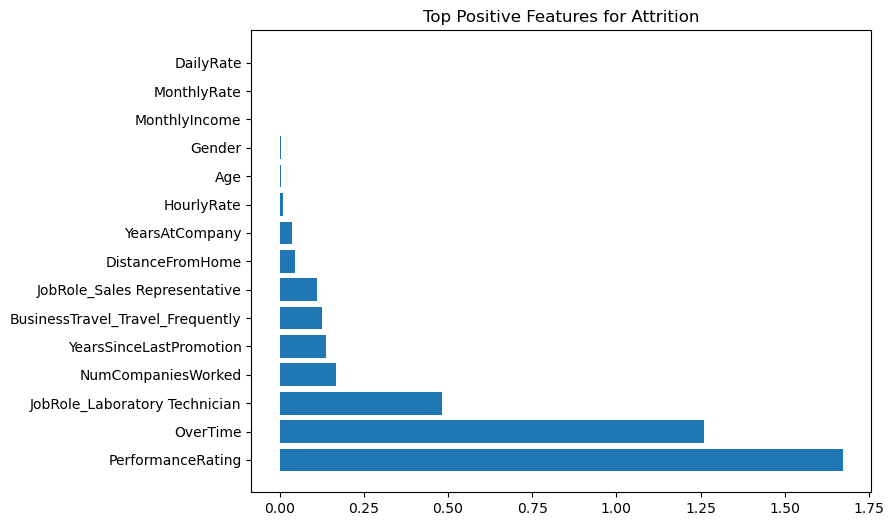

In [82]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(15))
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.title("Top Positive Features for Attrition")
plt.show()

In [99]:
#cross - validation 
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,      
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Mean AUC:", scores.mean())

[0.70879851 0.84223885 0.84076944 0.81659097 0.8665509 ]
Mean AUC: 0.8149897316742093


In [ ]:
# Final Conclusion
# Performed EDA to identify key factors affecting employee attrition.
# Applied data preprocessing, feature engineering, and handled class imbalance using SMOTE.
# Trained a Logistic Regression model with feature scaling.
# Evaluated the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
# Achieved a Test ROC-AUC of ~0.76 and Cross-Validation ROC-AUC of ~0.83.
# Threshold Analysis
# Threshold = 0.60
# Accuracy ≈ 87.8%
# Precision ≈ 72%
# Recall ≈ 38%
# Suitable when we want high-confidence attrition predictions and want to reduce false alarms.
# Optimized Threshold = 0.43
# Accuracy ≈ 84%
# Precision ≈ 50%
# Recall ≈ 51%
# Suitable when the goal is to identify more employees likely to leave and reduce missed attrition cases.
# Final Takeaway
# If the business prioritizes reliable predictions, use Threshold = 0.60.
# If the business prioritizes capturing more at-risk employees, use the optimized threshold (0.43).
# For HR retention strategies, the optimized threshold is often preferred because missing a potential attrition case can be more costly than investigating a false alert.